In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
print("PyTorch Version:", torch.__version__)
print("MPS (Apple Silicon GPU) Available:", torch.backends.mps.is_available())

PyTorch Version: 2.12.0
MPS (Apple Silicon GPU) Available: True


In [3]:
import torch

# Set device to Apple Silicon MPS (Metal Performance Shaders)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [13]:
import torchvision

# 1. Download the raw dataset
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)

# 2. Slice exactly what you need and drop straight into NumPy
# (e.g., Grabbing the first 100 images and labels)
images_np = mnist_dataset.data[:100].numpy()
images_np = images_np[:,None, :,:]
labels_np = mnist_dataset.targets[:100].numpy()

print("Images shape:", images_np.shape)  # Output: (100, 28, 28)
print("Data type:", images_np.dtype)     # Output: uint8 (Values 0 to 255)

Images shape: (100, 1, 28, 28)
Data type: uint8


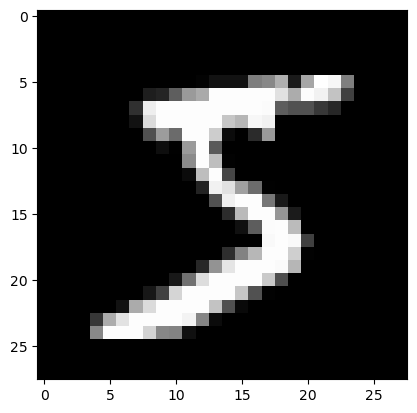

In [15]:
import matplotlib.pyplot as plt
plt.imshow(images_np[0,0,:,:], cmap ='grey')

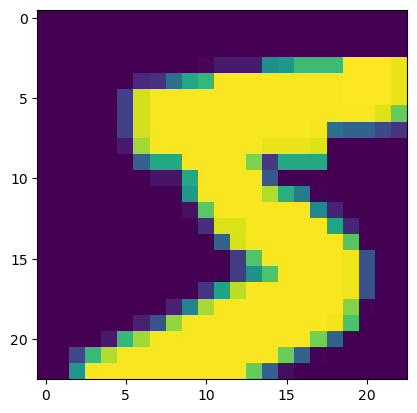

In [35]:
import numpy as np
def max_pool(x, kernel = (3,3), stride = 1):
    res_shape = (x.shape[0], x.shape[1], 
                 (x.shape[2]- 2 *kernel[0])//stride+1,
                 (x.shape[3]- 2 *kernel[1])//stride+1)
    
    res = np.zeros(shape = res_shape)
    
    for i in range(res.shape[-2]):
        for j in range(res.shape[-1]):
            h_start = i * stride
            w_start = j * stride
            
            res[:, :, i, j] = np.max(
                x[:, :, h_start : h_start + kernel[0], w_start : w_start + kernel[1]], 
                axis=(-1, -2)
            )
    return res

maxed = max_pool(images_np)
plt.imshow(maxed[0,0,:,:])

(2, 1, 3, 3)
(2, 1, 3, 3)


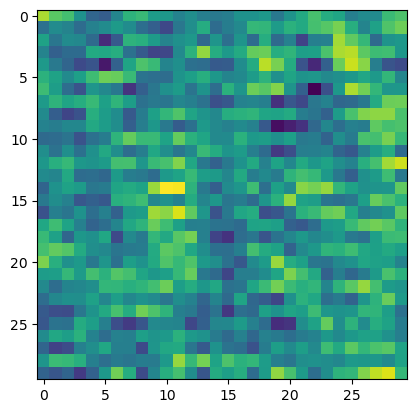

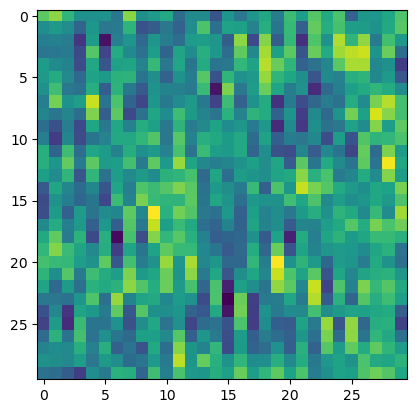

In [86]:
import numpy as np
def conv(x, kernel, stride = 1):
    res_shape = (x.shape[0], kernel.shape[0], 
                 (x.shape[2] - kernel.shape[2]) // stride + 1,      
                 (x.shape[3] - kernel.shape[3]) // stride + 1)
    
    res = np.zeros(shape = res_shape)
    size = np.size(kernel)
    kernel_stacked = kernel[None, :,:,:]
    kernel_stacked = np.repeat(kernel_stacked, x.shape[0], 0)
    for f in range(kernel.shape[0]):
        k = kernel_stacked[:,f,:,:]
        print(k.shape)
        for i in range(res.shape[-2]):
            for j in range(res.shape[-1]):
                h_start = i * stride
                w_start = j * stride
                sliced = x[:, :, h_start : h_start + k.shape[2], w_start : w_start + k.shape[3]]
                res[:, f, i, j] = np.sum(sliced * k, axis=(-3, -2, -1))
    return res

kernel = np.zeros((2,1,3,3))
kernel[0,0,0,:] = 10
kernel[0,0,-1,:] = 10

kernel[1,0,:,0] = 10
kernel[1,0,:,-1] = 10
conv_map = conv(images_np, kernel)
plt.figure()
plt.imshow(conv_map[0,0,:,:])
plt.figure()
plt.imshow(conv_map[0,1,:,:])

In [ ]:
def d_conv